# 📑 Section 1: Retrieving Libraries and Reading Data from Scratch

## Objective: To prepare the work environment and examine the initial file structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# # Read the original dirty file with memory lock warnings
df = pd.read_csv('amazon_dirty_data_1M.csv', low_memory=False)

# View file dimensions and initial overview
print(f"Dimensions of the original data: {df.shape}")
display(df.head())

Dimensions of the original data: (1015005, 20)


,Order_ID,Customer_ID,Customer_Name,Order_Date,Category,Product_Name,Base_Price,Quantity,Total_Amount,Payment_Type,Shipping_Class,Order_Status,Country,City,Postal_Code,Customer_Age,Customer_Gender,Product_Rating,Discount_Applied,Is_Prime_Member
0,AZ-685903,CUST-50592,User_13296,11/05/2024,Home & Kitchen,iPhone 15,68.318118,4,273.272472,Visa,Prime One-Day,Returned,CA,NaN,PC-5478,32.0,Female,4.3,False,0.0
1,AZ-289636,CUST-53545,User_11367,2024-12-29,Beauty,Coffee Maker,478.538566,8,3828.308526,Credit Card,Prime,Shipped,United Kingdom,NaN,PC-4422,32.0,Female,4.3,False,0.0
2,AZ-673977,CUST-55732,User_33330,2025-01-14,Home & Kitchen,T-Shirt,370.049501,1,370.049501,Cash,Standard,Cancelled,United Kingdom,New York,PC-4939,32.0,NaN,4.3,False,1.0
3,AZ-635030,CUST-55341,User_34234,2025-04-30,Clothing,T-Shirt,432.087381,3,1296.262142,Visa,Standard Shipping,delivered,US,NaN,PC-5400,32.0,Female,4.3,False,0.0
4,AZ-859363,CUST-54577,User_4471,"Sep 14, 2025",Clothing,Laptop Pro,119.218091,9,1072.962815,Cash,Standard,Cancelled,NaN,Los Angeles,PC-8355,32.0,F,NaN,True,1.0


# 📑 Section 2: Exploring NAs and Dates (Initial Auditing)
## Objective: To uncover gaps and correct dates, as these are fundamental to any chronological analysis.

In [2]:
# 1. Removing fully duplicated rows first to ensure data integrity
df = df.drop_duplicates()

# 2. Calculation and percentage of missing values
missing_df = pd.DataFrame({'Total NA': df.isnull().sum(), 'Percentage %': (df.isnull().sum() / len(df)) * 100})
display(missing_df[missing_df['Total NA'] > 0].sort_values(by='Percentage %', ascending=False))

# 3. Correcting mixed-form dates to fix texts such as (Sep 14, 2025)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed', errors='coerce')

# Fill in the damaged dates with the most frequently occurring date.
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])

# Extracting time columns
df['Year'] = df['Order_Date'].dt.year
df['Month_Name'] = df['Order_Date'].dt.strftime('%B')
df['Day_Name'] = df['Order_Date'].dt.strftime('%A')
df['Quarter'] = df['Order_Date'].dt.to_period('Q').astype(str)

print(f"✅ Duplicates dropped and dates fixed! Current shape: {df.shape}")

,Total NA,Percentage %
Is_Prime_Member,332939,33.293734
City,199561,19.956000
Customer_Gender,199294,19.929300
Order_Status,167276,16.727516
Shipping_Class,166649,16.664817
Product_Rating,130202,13.020135
Country,124657,12.465638
Customer_Age,100262,10.026150
Postal_Code,99928,9.992750


✅ Duplicates dropped and dates fixed! Current shape: (1000005, 24)


# 📑 Section 3: Standardization of Texts and Geographic Data

## Objective: To eliminate randomness in the names of countries, payment methods, sections, and to remove random nonsense of duplicate categories.

In [3]:
# 1. Cleaning up extra spaces in texts
df['Product_Name'] = df['Product_Name'].str.strip()
df['City'] = df['City'].str.strip()

# 2. Eliminate the random mixing of sections and correct them based on the product's business logic.
correct_category_map = {
    'iPhone 15': 'Electronics', 'Laptop Pro': 'Electronics',
    'Blender 3000': 'Home & Kitchen', 'Coffee Maker': 'Home & Kitchen',
    'T-Shirt': 'Clothing', 'Nike Shoes': 'Clothing',
    'Lipstick': 'Beauty', 'Python Book': 'Books'
}
df['Category'] = df['Product_Name'].map(correct_category_map)

# 3. Unifying payment methods
df['Payment_Type'] = df['Payment_Type'].str.strip().str.lower().map({'visa': 'Visa', 'credit card': 'Credit Card', 'paypal': 'PayPal', 'cash': 'Cash'}).fillna('Unknown')

# 4. Unify shipping, type, order status, and Prime customer
df['Shipping_Class'] = df['Shipping_Class'].map({'Prime One-Day': 'Prime', 'Prime': 'Prime', 'Standard': 'Standard', 'Standard Shipping': 'Standard', 'Express': 'Express'}).fillna('Standard')
df['Order_Status'] = df['Order_Status'].str.strip().str.capitalize().fillna('Unknown')
df['Customer_Gender'] = df['Customer_Gender'].map({'Female': 'Female', 'F': 'Female', 'Male': 'Male', 'M': 'Male'}).fillna('Unspecified')
df['Is_Prime_Member'] = df['Is_Prime_Member'].map({0: 'Regular Customer', 1: 'Prime Customer'}).fillna('Regular Customer')

# 5. Smart geo-mobilization of countries based on city
city_to_country = {'New York': 'United States', 'Los Angeles': 'United States', 'Toronto': 'Canada', 'London': 'United Kingdom'}
df['Country'] = df['Country'].map({'US': 'United States', 'USA': 'United States', 'United States': 'United States', 'UK': 'United Kingdom', 'United Kingdom': 'United Kingdom', 'CA': 'Canada', 'Canada': 'Canada'})
df['Country'] = df['Country'].fillna(df['City'].map(city_to_country)).fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
df['Postal_Code'] = df['Postal_Code'].fillna('Unknown')

# 6. Delete Unhelpful Columns
# These two columns were deleted because their values were fixed and would not be useful for the analysis.
df = df.drop(columns=['Customer_Age', 'Product_Rating'], errors='ignore')
print("✅ Texts and geography have been standardized and redundant columns have been removed!")

✅ Texts and geography have been standardized and redundant columns have been removed!


# 📑 Section 4: Data Purging & Outliers

## Objective: To examine outliers (negative values and the fictitious 9999.99) by plotting before-and-after graphs to demonstrate the data purging process for yourself.

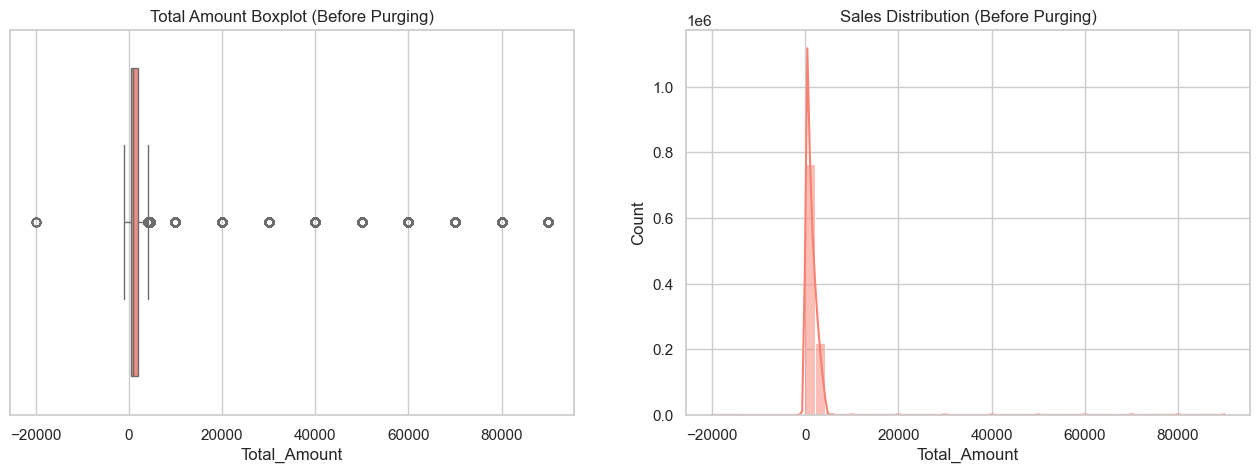

In [4]:
# Setting up the graph panel to visualize distortion (negative values and the long tail of 90,000)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Drawing the contaminated boxplot
sns.boxplot(x=df['Total_Amount'], ax=axes[0], color='salmon')
axes[0].set_title('Total Amount Boxplot (Before Purging)')

# Drawing the contaminated histogram
sns.histplot(df['Total_Amount'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Sales Distribution (Before Purging)')

# Saving and displaying drawings
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')

plt.show()

In [5]:
# Cut negative quantities and fictitious prices 9999.99
df = df[(df['Quantity'] > 0) & (df['Base_Price'] < 9999.99)]

# Saving the final clean file to SQL
df.to_csv('amazon_clean_data.csv', index=False)
print(f"🧹 The deletion is complete! The clean and final data size is now: {df.shape[0]} line.")

🧹 The deletion is complete! The clean and final data size is now: 992017 line.


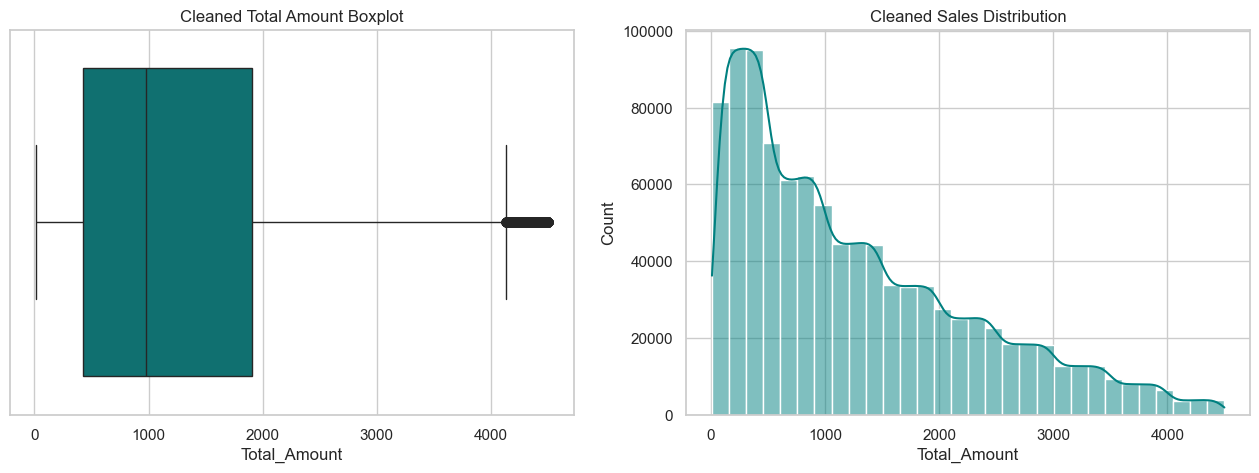

In [6]:
# Redraw data after cleansing to see the ideal normal distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x=df['Total_Amount'], ax=axes[0], color='teal')
axes[0].set_title('Cleaned Total Amount Boxplot')

sns.histplot(df['Total_Amount'], bins=30, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Cleaned Sales Distribution')

# Saving and displaying drawings
plt.savefig('my_plot_after.png', dpi=300, bbox_inches='tight')

plt.show()

# 📑 Section 5: Advanced Exploratory Analysis and Advanced Statistics (EDA & Analytics)

## Objective: To apply the relationships, correlations, and inferential statistical tests we have agreed upon to produce a consulting report.

📊 Final Statistical Summary:


,Base_Price,Quantity,Total_Amount
count,992017.000000,992017.000000,992017.000000
mean,255.028863,4.999718,1275.411943
std,141.474858,2.584190,1033.919628
min,10.000103,1.000000,10.000243
25%,132.509210,3.000000,421.285494
50%,255.048287,5.000000,981.169549
75%,377.664012,7.000000,1906.687878
max,499.999392,9.000000,4499.960840


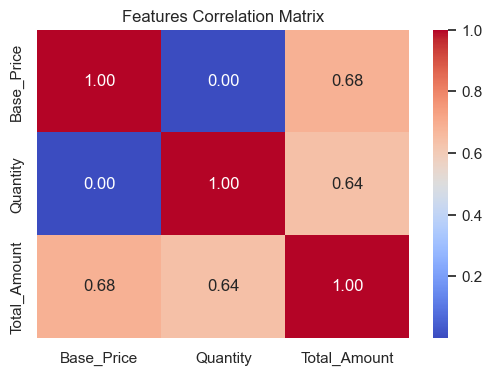

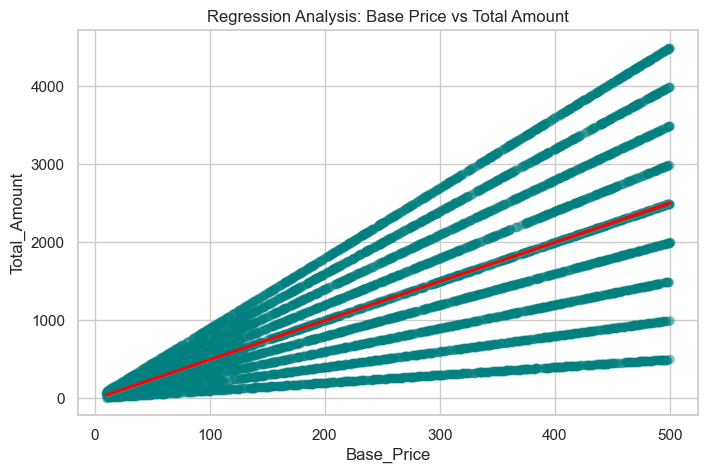

In [7]:
# 1. Print the clean final descriptive statistics table
print("📊 Final Statistical Summary:")
display(df[['Base_Price', 'Quantity', 'Total_Amount']].describe())

# 2. Drawing the Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Base_Price', 'Quantity', 'Total_Amount']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Features Correlation Matrix')
plt.savefig('Correlation Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Draw a regression plot for a sample of data to avoid slow graphing.
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(10000), x='Base_Price', y='Total_Amount', scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Regression Analysis: Base Price vs Total Amount')
plt.savefig('Regression Plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print("🔬 Running Applied Statistics Tests & Business Interpretations...")
print("=" * 70)

# =========================================================================
# A. T-test for Prime customer spending
# =========================================================================
prime_spending = df[df['Is_Prime_Member'] == 'Prime Customer']['Total_Amount']
regular_spending = df[df['Is_Prime_Member'] == 'Regular Customer']['Total_Amount']

# Calculate averages first to present them as understandable numbers for the viewer
mean_prime = prime_spending.mean()
mean_regular = regular_spending.mean()

t_stat, p_val_t = stats.ttest_ind(prime_spending, regular_spending, equal_var=False)

print(f"🔹 1. [T-Test] Comparing Spending Behavior:")
print(f"   - Average Prime Customer Spending: ${mean_prime:.2f}")
print(f"   - Average Regular Customer Spending: ${mean_regular:.2f}")
print(f"   - Statistical P-value: {p_val_t}")

# Intelligent automatic system interpretation
if p_val_t < 0.05:
    print("📢 RESULT: Significant Difference Mapped!")
    print("    💡 Business explanation: There is a substantial and real difference in Prime customers' spending rate.")
    print("    The Prime subscription actually impacts sales growth, and the result is not a mere coincidence.")
else:
    print("📢 RESULT: No Significant Difference.")
    print("    💡 Business explanation: The difference between spending by Prime customers and regular customers is very small and consistent.")
    print("    It may simply be due to randomness of the data; a Prime subscription does not currently make a financial difference.")

print("-" * 70)

# ===============================================================================
# B. Chi-Square test of the relationship between payment method and order status
# ===============================================================================
contingency_table = pd.crosstab(df['Payment_Type'], df['Order_Status'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"🔹 2. [Chi-Square Test] Payment Type vs Order Status:")
print(f"   - Statistical P-value: {p_val_chi}")

# Intelligent automatic system interpretation
if p_val_chi < 0.05:
    print("📢 RESULT: Strong Dependency Detected!")
    print("    💡 Business Interpretation: There is a close statistical relationship between 'payment method' and 'final order status'.")
    print("    Customer behavior regarding cancellations or returns varies greatly depending on their payment method (e.g. cash may cause higher cancellations).")
else:
    print("📢 RESULT: No Dependency Found.")
    print("   💡 Business explanation: There is no relationship between the payment method and the order status.")
    print("   The customer cancels or receives their order completely independently of whether they paid by Visa or cash.")
print("=" * 70)

🔬 Running Applied Statistics Tests & Business Interpretations...
🔹 1. [T-Test] Comparing Spending Behavior:
   - Average Prime Customer Spending: $1275.35
   - Average Regular Customer Spending: $1275.44
   - Statistical P-value: 0.9653444140005061
📢 RESULT: No Significant Difference.
    💡 Business explanation: The difference between spending by Prime customers and regular customers is very small and consistent.
    It may simply be due to randomness of the data; a Prime subscription does not currently make a financial difference.
----------------------------------------------------------------------
🔹 2. [Chi-Square Test] Payment Type vs Order Status:
   - Statistical P-value: 0.8523166715625734
📢 RESULT: No Dependency Found.
   💡 Business explanation: There is no relationship between the payment method and the order status.
   The customer cancels or receives their order completely independently of whether they paid by Visa or cash.
